GPU disponible: Tesla T4
Datos cargados y agrupados en 111 secuencias únicas.
Vocabulario construido con 113 palabras.
Datos listos: 94 para entrenamiento, 17 para validación.

--- Iniciando Entrenamiento del Modelo Seq2Seq ---


/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:508: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Epoch: 001 | Train Loss: 4.7675 | Val Loss: 4.1065 | Val MAE: 1.6401 | Val Acc: 2.69%
 -> Checkpoint guardado (mejor Val MAE: 1.6401)
Epoch: 002 | Train Loss: 3.9772 | Val Loss: 3.5894 | Val MAE: 1.5351 | Val Acc: 3.46%
 -> Checkpoint guardado (mejor Val MAE: 1.5351)
Epoch: 003 | Train Loss: 3.5514 | Val Loss: 3.2941 | Val MAE: 1.4801 | Val Acc: 2.76%
 -> Checkpoint guardado (mejor Val MAE: 1.4801)
Epoch: 004 | Train Loss: 3.2872 | Val Loss: 3.0906 | Val MAE: 1.4442 | Val Acc: 3.12%
 -> Checkpoint guardado (mejor Val MAE: 1.4442)
Epoch: 005 | Train Loss: 3.0993 | Val Loss: 2.9363 | Val MAE: 1.4221 | Val Acc: 3.05%
 -> Checkpoint guardado (mejor Val MAE: 1.4221)
Epoch: 006 | Train Loss: 2.9494 | Val Loss: 2.8066 | Val MAE: 1.4066 | Val Acc: 2.92%
 -> Checkpoint guardado (mejor Val MAE: 1.4066)
Epoch: 007 | Train Loss: 2.8238 | Val Loss: 2.6942 | Val MAE: 1.3949 | Val Acc: 2.21%
 -> Checkpoint guardado (mejor Val MAE: 1.3949)
Epoch: 008 | Train Loss: 2.7105 | Val Loss: 2.5922 | Val MAE: 

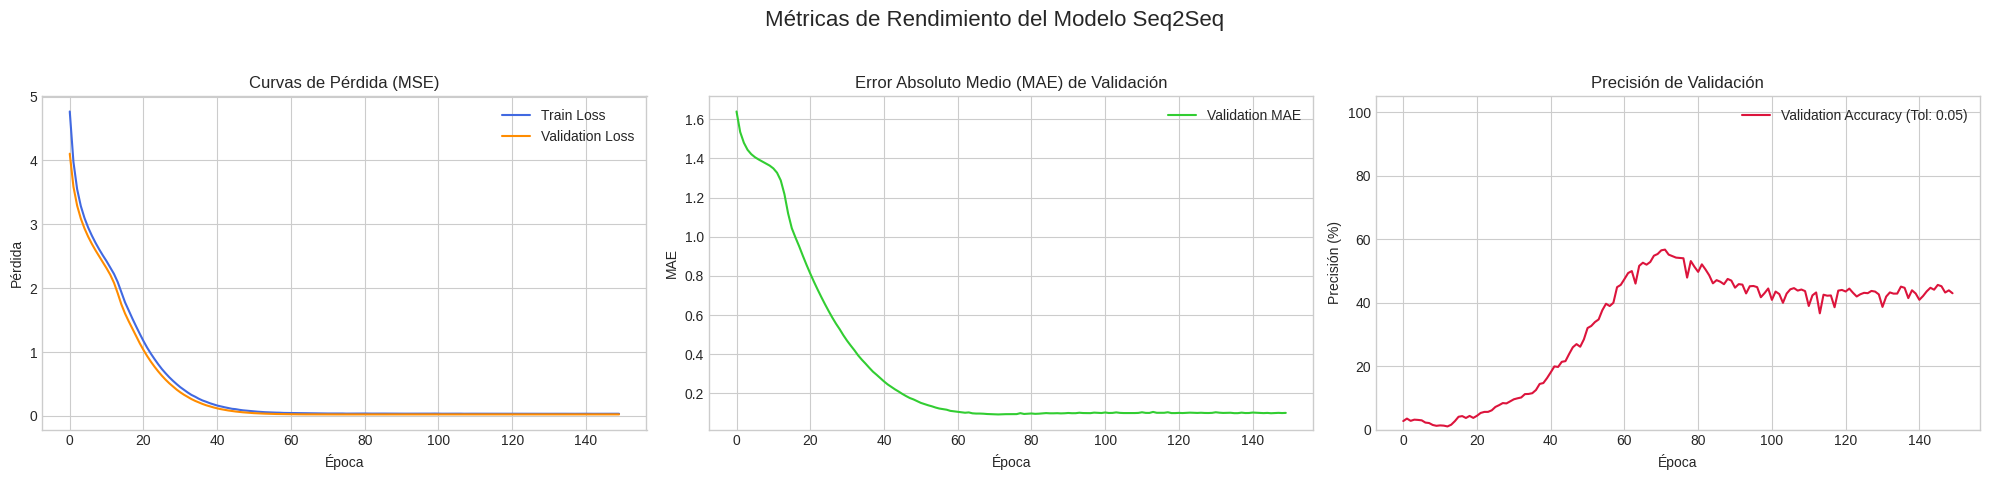


--- Generando Visualización 3D Comparativa ---
Palabra de muestra: '40'


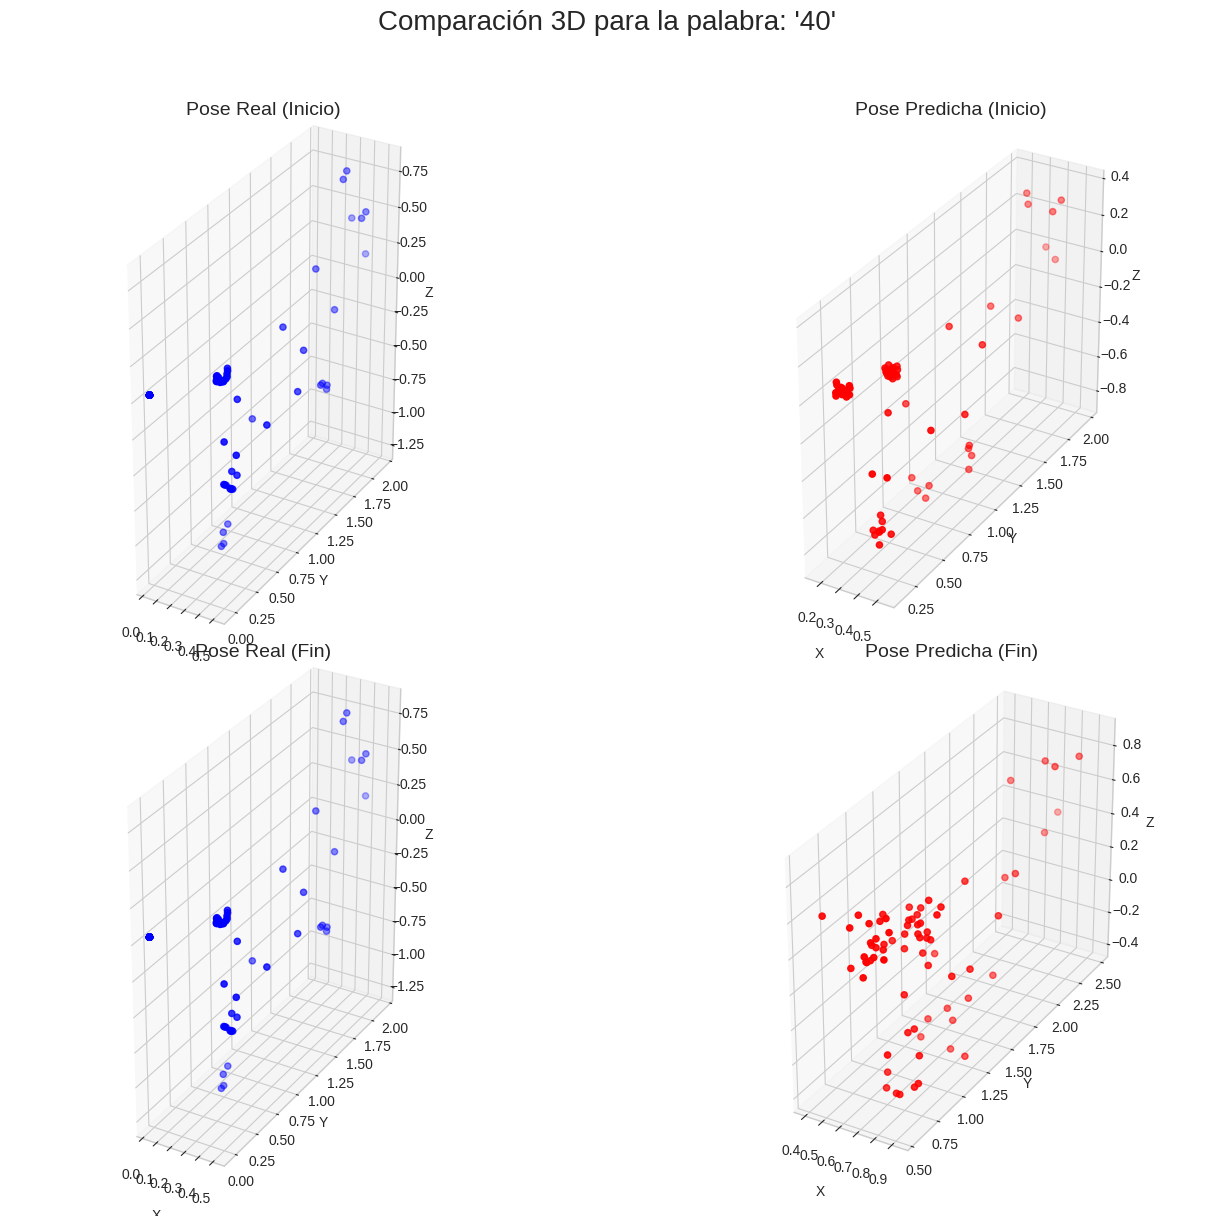

In [1]:
# -*- coding: utf-8 -*-
# @title Texto a Secuencia de Poses con Seq2Seq Transformer (v3 - Completo)
# Este script implementa un modelo Seq2Seq para traducir una palabra a una secuencia de movimiento.
# VERSIÓN 3: Incluye métricas de rendimiento (Loss, MAE, Precisión) Y
# visualizaciones 3D comparativas de poses reales vs. predichas.

# --- 1. CONFIGURACIÓN INICIAL ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence

import json
import math
import random
import numpy as np
from collections import Counter, defaultdict
import matplotlib.pyplot as plt

# Configuración de GPU
if torch.cuda.is_available():
    print(f"GPU disponible: {torch.cuda.get_device_name(0)}")
    device = torch.device('cuda')
else:
    print("No se encontró GPU. Usando CPU.")
    device = torch.device('cpu')

# --- 2. DEFINICIÓN DE LANDMARKS Y CONSTANTES ---
BODY_LANDMARKS = [
    "NOSE", "LEFT_EYE_INNER", "LEFT_EYE", "LEFT_EYE_OUTER", "RIGHT_EYE_INNER",
    "RIGHT_EYE", "RIGHT_EYE_OUTER", "LEFT_EAR", "RIGHT_EAR", "MOUTH_LEFT",
    "MOUTH_RIGHT", "LEFT_SHOULDER", "RIGHT_SHOULDER", "LEFT_ELBOW", "RIGHT_ELBOW",
    "LEFT_WRIST", "RIGHT_WRIST", "LEFT_PINKY", "RIGHT_PINKY", "LEFT_INDEX",
    "RIGHT_INDEX", "LEFT_THUMB", "RIGHT_THUMB", "LEFT_HIP", "RIGHT_HIP",
    "LEFT_KNEE", "RIGHT_KNEE", "LEFT_ANKLE", "RIGHT_ANKLE", "LEFT_HEEL",
    "RIGHT_HEEL", "LEFT_FOOT_INDEX", "RIGHT_FOOT_INDEX"
]
HAND_LANDMARKS = [
    "WRIST", "THUMB_CMC", "THUMB_MCP", "THUMB_IP", "THUMB_TIP", "INDEX_FINGER_MCP",
    "INDEX_FINGER_PIP", "INDEX_FINGER_DIP", "INDEX_FINGER_TIP", "MIDDLE_FINGER_MCP",
    "MIDDLE_FINGER_PIP", "MIDDLE_FINGER_DIP", "MIDDLE_FINGER_TIP", "RING_FINGER_MCP",
    "RING_FINGER_PIP", "RING_FINGER_DIP", "RING_FINGER_TIP", "PINKY_MCP",
    "PINKY_PIP", "PINKY_DIP", "PINKY_TIP"
]

NUM_BODY_LANDMARKS = len(BODY_LANDMARKS)
NUM_HAND_LANDMARKS = len(HAND_LANDMARKS)
TOTAL_LANDMARKS = NUM_BODY_LANDMARKS + (2 * NUM_HAND_LANDMARKS)
POSE_DIM = TOTAL_LANDMARKS * 3

# --- 3. HIPERPARÁMETROS ---
VOCAB_SIZE = None
DATASET_FILE = 'metadata_capstone_completo.json'

# Modelo
EMB_SIZE = 256
NUM_HEADS = 8
NUM_ENCODER_LAYERS = 3
NUM_DECODER_LAYERS = 3
FFN_DIM = 512
DROP_OUT = 0.1
MAX_POSE_SEQ_LEN = 100

# Entrenamiento
BATCH_SIZE = 32
LR = 1e-4
EPOCHS = 150
PREDICTION_TOLERANCE = 0.05

# Tokens Especiales
PAD_IDX, UNK_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3

# --- 4. PREPROCESAMIENTO DE DATOS ---
def load_and_group_data(filepath):
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            raw_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo {filepath}")
        return None
    grouped_sequences = defaultdict(list)
    for frame in raw_data:
        key = (frame.get('fuente_video'), frame.get('palabra_etiquetada'))
        if key[0] and key[1]:
            grouped_sequences[key].append(frame)
    for key in grouped_sequences:
        grouped_sequences[key].sort(key=lambda x: x.get('timestamp', 0))
    print(f"Datos cargados y agrupados en {len(grouped_sequences)} secuencias únicas.")
    return list(grouped_sequences.values())

def extract_pose_vector(frame):
    pose_vector = np.zeros(POSE_DIM, dtype=np.float32)
    body_map = {lm['name']: lm for lm in frame.get('body', []) if 'name' in lm}
    hands_map = {'Left': {}, 'Right': {}}
    for lm in frame.get('hands', []):
        if 'hand' in lm and 'name' in lm:
            hands_map[lm['hand']][lm['name']] = lm
    for i, name in enumerate(BODY_LANDMARKS):
        idx = i * 3
        if name in body_map:
            pose_vector[idx:idx+3] = [body_map[name].get('x',0), body_map[name].get('y',0), body_map[name].get('z',0)]
    offset = NUM_BODY_LANDMARKS * 3
    for i, name in enumerate(HAND_LANDMARKS):
        idx_l = offset + i * 3
        if name in hands_map['Left']:
            lm = hands_map['Left'][name]
            pose_vector[idx_l:idx_l+3] = [lm.get('x',0), lm.get('y',0), lm.get('z',0)]
        idx_r = offset + NUM_HAND_LANDMARKS * 3 + i * 3
        if name in hands_map['Right']:
            lm = hands_map['Right'][name]
            pose_vector[idx_r:idx_r+3] = [lm.get('x',0), lm.get('y',0), lm.get('z',0)]
    return pose_vector

class SignPoseSequenceDataset(Dataset):
    def __init__(self, data, text_vocab, max_pose_len):
        self.data = data
        self.text_vocab = text_vocab
        self.max_pose_len = max_pose_len
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        sequence = self.data[idx]
        palabra = str(sequence[0]['palabra_etiquetada'])
        text_tensor = torch.tensor([self.text_vocab.get(palabra, UNK_IDX)], dtype=torch.long)
        pose_sequence = [extract_pose_vector(frame) for frame in sequence]
        if len(pose_sequence) > self.max_pose_len:
            pose_sequence = pose_sequence[:self.max_pose_len]
        pose_tensor = torch.FloatTensor(np.array(pose_sequence))
        return palabra, text_tensor, pose_tensor

def build_vocab(data):
    counter = Counter()
    for seq in data:
        counter[str(seq[0]['palabra_etiquetada'])] += 1
    vocab = {'<pad>': PAD_IDX, '<unk>': UNK_IDX, '<bos>': BOS_IDX, '<eos>': EOS_IDX}
    for word in counter:
        if word not in vocab:
            vocab[word] = len(vocab)
    global VOCAB_SIZE
    VOCAB_SIZE = len(vocab)
    print(f"Vocabulario construido con {VOCAB_SIZE} palabras.")
    return vocab, {v: k for k, v in vocab.items()}

def generate_batch(data_batch):
    text_batch, pose_batch = [], []
    for (_, text_item, pose_item) in data_batch: # Ignoramos la palabra en string
        processed_text = torch.cat([torch.tensor([BOS_IDX]), text_item, torch.tensor([EOS_IDX])], dim=0)
        text_batch.append(processed_text)
        bos_pose = torch.full((1, POSE_DIM), BOS_IDX, dtype=torch.float)
        eos_pose = torch.full((1, POSE_DIM), EOS_IDX, dtype=torch.float)
        pose_batch.append(torch.cat([bos_pose, pose_item, eos_pose], dim=0))
    text_batch_padded = pad_sequence(text_batch, batch_first=True, padding_value=PAD_IDX)
    pose_batch_padded = pad_sequence(pose_batch, batch_first=True, padding_value=PAD_IDX)
    return text_batch_padded, pose_batch_padded

# --- 5. DEFINICIÓN DEL MODELO SEQ2SEQ TRANSFORMER ---
class PositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, dropout: float, maxlen: int = 5000):
        super(PositionalEncoding, self).__init__()
        den = torch.exp(-torch.arange(0, emb_size, 2) * math.log(10000) / emb_size)
        pos = torch.arange(0, maxlen).reshape(maxlen, 1)
        pos_embedding = torch.zeros((maxlen, emb_size))
        pos_embedding[:, 0::2] = torch.sin(pos * den)
        pos_embedding[:, 1::2] = torch.cos(pos * den)
        pos_embedding = pos_embedding.unsqueeze(0)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('pos_embedding', pos_embedding)
    def forward(self, token_embedding):
        seq_len = token_embedding.size(1)
        return self.dropout(token_embedding + self.pos_embedding[:, :seq_len, :])

class Seq2SeqTransformer(nn.Module):
    def __init__(self, num_encoder_layers: int, num_decoder_layers: int, emb_size: int, num_heads: int, src_vocab_size: int, pose_dim: int, ffn_dim: int = 512, dropout: float = 0.1):
        super(Seq2SeqTransformer, self).__init__()
        self.emb_size = emb_size
        self.positional_encoding = PositionalEncoding(emb_size, dropout)
        self.src_tok_emb = nn.Embedding(src_vocab_size, emb_size)
        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_size, nhead=num_heads, dim_feedforward=ffn_dim, dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)
        self.tgt_pose_emb = nn.Linear(pose_dim, emb_size)
        decoder_layer = nn.TransformerDecoderLayer(d_model=emb_size, nhead=num_heads, dim_feedforward=ffn_dim, dropout=dropout, batch_first=True)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_decoder_layers)
        self.generator = nn.Linear(emb_size, pose_dim)
    def forward(self, src, tgt, src_padding_mask, tgt_padding_mask, memory_key_padding_mask, tgt_mask):
        src_emb = self.positional_encoding(self.src_tok_emb(src) * math.sqrt(self.emb_size))
        memory = self.transformer_encoder(src_emb, src_key_padding_mask=src_padding_mask)
        tgt_emb = self.positional_encoding(self.tgt_pose_emb(tgt))
        outs = self.transformer_decoder(tgt_emb, memory, tgt_mask=tgt_mask, tgt_key_padding_mask=tgt_padding_mask, memory_key_padding_mask=memory_key_padding_mask)
        return self.generator(outs)
    def encode(self, src, src_mask):
        return self.transformer_encoder(self.positional_encoding(self.src_tok_emb(src) * math.sqrt(self.emb_size)), src_mask)
    def decode(self, tgt, memory, tgt_mask):
        tgt_emb = self.positional_encoding(self.tgt_pose_emb(tgt))
        return self.transformer_decoder(tgt_emb, memory, tgt_mask)

def generate_square_subsequent_mask(sz):
    mask = (torch.triu(torch.ones((sz, sz), device=device)) == 1).transpose(0, 1)
    mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
    return mask

def create_mask(src, tgt):
    src_seq_len = src.shape[1]
    tgt_seq_len = tgt.shape[1]
    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=device).type(torch.bool)
    src_padding_mask = (src == PAD_IDX)
    tgt_padding_mask = (tgt[:, :, 0] == PAD_IDX)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

# --- 6. BUCLES DE ENTRENAMIENTO Y EVALUACIÓN ---
def train_one_epoch(model, optimizer, criterion, dataloader):
    model.train()
    total_loss = 0
    for src, tgt in dataloader:
        src, tgt = src.to(device), tgt.to(device)
        tgt_input = tgt[:, :-1, :]
        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input)
        logits = model(src, tgt_input, src_padding_mask, tgt_padding_mask, src_padding_mask, tgt_mask)
        optimizer.zero_grad()
        tgt_out = tgt[:, 1:, :]
        loss = criterion(logits, tgt_out)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def evaluate_model(model, criterion, dataloader, tolerance):
    model.eval()
    total_loss, all_maes, all_accuracies = 0, [], []
    with torch.no_grad():
        for src, tgt in dataloader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_input = tgt[:, :-1, :]
            src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(src, tgt_input)
            logits = model(src, tgt_input, src_padding_mask, tgt_padding_mask, src_padding_mask, tgt_mask)
            tgt_out = tgt[:, 1:, :]
            loss = criterion(logits, tgt_out)
            total_loss += loss.item()
            non_pad_mask = (tgt_out[:, :, 0] != PAD_IDX).unsqueeze(-1).expand_as(tgt_out)
            predictions_flat = logits[non_pad_mask]
            targets_flat = tgt_out[non_pad_mask]
            all_maes.append(torch.abs(predictions_flat - targets_flat).mean().item())
            correct_coords = torch.abs(predictions_flat - targets_flat) <= tolerance
            all_accuracies.append((torch.mean(correct_coords.float()) * 100).item())
    return total_loss / len(dataloader), np.mean(all_maes), np.mean(all_accuracies)

# --- 7. EJECUCIÓN PRINCIPAL ---
grouped_data = load_and_group_data(DATASET_FILE)
if not grouped_data:
    exit()

vocab, idx_to_word = build_vocab(grouped_data)
full_dataset = SignPoseSequenceDataset(grouped_data, vocab, MAX_POSE_SEQ_LEN)
train_size = int(0.85 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=generate_batch)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=generate_batch)
print(f"Datos listos: {len(train_dataset)} para entrenamiento, {len(val_dataset)} para validación.")

model = Seq2SeqTransformer(NUM_ENCODER_LAYERS, NUM_DECODER_LAYERS, EMB_SIZE, NUM_HEADS, VOCAB_SIZE, POSE_DIM, FFN_DIM, DROP_OUT).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LR)
print("\n--- Iniciando Entrenamiento del Modelo Seq2Seq ---")
best_val_mae = float('inf')
path_to_save_best_model = 'best_seq2seq_pose_model_final.pth'
train_losses, val_losses, val_maes, val_accuracies = [], [], [], []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, optimizer, criterion, train_dataloader)
    val_loss, val_mae, val_acc = evaluate_model(model, criterion, val_dataloader, PREDICTION_TOLERANCE)
    train_losses.append(train_loss); val_losses.append(val_loss); val_maes.append(val_mae); val_accuracies.append(val_acc)
    print(f"Epoch: {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val MAE: {val_mae:.4f} | Val Acc: {val_acc:.2f}%")
    # ... dentro del bucle de entrenamiento ...
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        # Guardar un diccionario con todo lo necesario para la inferencia
        checkpoint = {
            'model_state_dict': model.state_dict(),
            'vocab': vocab,
            'model_args': {
                'num_encoder_layers': NUM_ENCODER_LAYERS,
                'num_decoder_layers': NUM_DECODER_LAYERS,
                'emb_size': EMB_SIZE,
                'num_heads': NUM_HEADS,
                'src_vocab_size': VOCAB_SIZE,
                'pose_dim': POSE_DIM,
                'ffn_dim': FFN_DIM,
                'dropout': DROP_OUT,
            }
        }
        torch.save(checkpoint, path_to_save_best_model)
        print(f" -> Checkpoint guardado (mejor Val MAE: {best_val_mae:.4f})")

# --- 8. GRÁFICOS DE RENDIMIENTO ---
print("\n--- Generando Gráficos de Rendimiento ---")
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Métricas de Rendimiento del Modelo Seq2Seq', fontsize=16)
ax1.plot(train_losses, label='Train Loss', color='royalblue')
ax1.plot(val_losses, label='Validation Loss', color='darkorange')
ax1.set_title('Curvas de Pérdida (MSE)'); ax1.set_xlabel('Época'); ax1.set_ylabel('Pérdida'); ax1.legend()
ax2.plot(val_maes, label='Validation MAE', color='limegreen')
ax2.set_title('Error Absoluto Medio (MAE) de Validación'); ax2.set_xlabel('Época'); ax2.set_ylabel('MAE'); ax2.legend()
ax3.plot(val_accuracies, label=f'Validation Accuracy (Tol: {PREDICTION_TOLERANCE})', color='crimson')
ax3.set_title('Precisión de Validación'); ax3.set_xlabel('Época'); ax3.set_ylabel('Precisión (%)'); ax3.set_ylim(0, 105); ax3.legend()
plt.tight_layout(rect=[0, 0.03, 1, 0.95]); plt.show()

# --- 9. INFERENCIA Y VISUALIZACIÓN 3D COMPARATIVA ---
def translate(model, text_tensor, max_len=MAX_POSE_SEQ_LEN):
    model.eval()
    src = torch.cat([torch.tensor([[BOS_IDX]]), text_tensor.view(1, -1), torch.tensor([[EOS_IDX]])], dim=1).to(device)
    with torch.no_grad():
        memory = model.encode(src, src_mask=None)
    ys = torch.full((1, 1, POSE_DIM), BOS_IDX, dtype=torch.float).to(device)
    for i in range(max_len - 1):
        with torch.no_grad():
            tgt_mask = generate_square_subsequent_mask(ys.size(1)).to(device)
            out = model.decode(ys, memory, tgt_mask)
            last_pred = model.generator(out[:, -1, :]).unsqueeze(1)
            ys = torch.cat([ys, last_pred], dim=1)
    return ys.squeeze(0)[1:]

print("\n--- Generando Visualización 3D Comparativa ---")
# Load the checkpoint and then load the model state dict from the checkpoint
checkpoint = torch.load(path_to_save_best_model)
model.load_state_dict(checkpoint['model_state_dict'])


# Tomar una muestra aleatoria del dataset de validación
sample_idx = random.randint(0, len(val_dataset) - 1)
palabra_real, texto_tensor_real, pose_tensor_real = val_dataset[sample_idx]

print(f"Palabra de muestra: '{palabra_real}'")

# Generar la secuencia predicha
pose_predicha_tensor = translate(model, texto_tensor_real)

# Preparar datos para graficar (convertir a numpy y remodelar)
pose_real_np = pose_tensor_real.numpy().reshape(-1, TOTAL_LANDMARKS, 3)
pose_pred_np = pose_predicha_tensor.cpu().detach().numpy().reshape(-1, TOTAL_LANDMARKS, 3)

# Tomar la primera y última pose de cada secuencia
pose_real_inicio = pose_real_np[0]
pose_real_fin = pose_real_np[-1]
pose_pred_inicio = pose_pred_np[0]
pose_pred_fin = pose_pred_np[-1]

# Crear la figura para los gráficos
fig = plt.figure(figsize=(15, 12))
fig.suptitle(f"Comparación 3D para la palabra: '{palabra_real}'", fontsize=20)

# Función auxiliar para graficar una pose
def plot_pose_3d(ax, pose_data, title, color):
    ax.scatter(pose_data[:, 0], pose_data[:, 1], pose_data[:, 2], c=color, marker='o')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("X"); ax.set_ylabel("Y"); ax.set_zlabel("Z")
    # Escalar ejes para una comparación justa
    ax.set_box_aspect([np.ptp(pose_data[:,0]), np.ptp(pose_data[:,1]), np.ptp(pose_data[:,2])])


# Graficar las 4 poses
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
plot_pose_3d(ax1, pose_real_inicio, "Pose Real (Inicio)", "blue")

ax2 = fig.add_subplot(2, 2, 2, projection='3d')
plot_pose_3d(ax2, pose_pred_inicio, "Pose Predicha (Inicio)", "red")

ax3 = fig.add_subplot(2, 2, 3, projection='3d')
plot_pose_3d(ax3, pose_real_fin, "Pose Real (Fin)", "blue")

ax4 = fig.add_subplot(2, 2, 4, projection='3d')
plot_pose_3d(ax4, pose_pred_fin, "Pose Predicha (Fin)", "red")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()